In [22]:
import cv2
import pytesseract
import re
import numpy as np

def fix_orientation_robust(image_path):
    # 1. Đọc ảnh
    img = cv2.imread(image_path)
    if img is None:
        print("Không đọc được ảnh")
        return None, None

    # --- BƯỚC TIỀN XỬ LÝ QUAN TRỌNG ---
    # Chuyển sang ảnh xám
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Dùng GaussianBlur để làm mờ nhẹ, giúp các chấm dot-matrix "dính" lại với nhau
    # Kích thước kernel (5,5) có thể điều chỉnh tùy độ phân giải ảnh
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Dùng Adaptive Threshold để tách chữ khỏi nền kể cả khi ánh sáng không đều
    # Biến ảnh thành đen trắng (Chữ đen nền trắng hoặc ngược lại đều được với OSD)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY, 11, 2)
    
    # (Tùy chọn) Đảo ngược màu nếu cần, Tesseract thường thích chữ đen nền trắng
    # thresh = cv2.bitwise_not(thresh)
    
    # Để debug: Bạn có thể cv2.imshow('Processed', thresh) để xem text đã rõ chưa
    
    try:
        # Cấu hình psm 0: Orientation and script detection (OSD) only.
        results = pytesseract.image_to_osd(thresh, config='--psm 0')
        
        # Regex lấy góc xoay
        rotation_angle = int(re.search(r'(?<=Rotate: )\d+', results).group(0))
        confidence = float(re.search(r'(?<=Orientation confidence: )[\d\.]+', results).group(0))

        print(f"[INFO] Detected rotation: {rotation_angle} degrees")
        print(f"[INFO] Confidence: {confidence}")

        # Xoay ảnh GỐC dựa trên kết quả phân tích ảnh thresh
        if rotation_angle == 90:
            rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        elif rotation_angle == 180:
            rotated = cv2.rotate(img, cv2.ROTATE_180)
        elif rotation_angle == 270:
            rotated = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
        else:
            rotated = img

        return rotated, img

    except Exception as e:
        # Nếu vẫn lỗi, thường là do ảnh quá ít chữ hoặc nhiễu quá nặng
        print(f"[WARNING] Tesseract OSD thất bại: {e}")
        print("[INFO] Trả về ảnh gốc.")
        return img, img


In [23]:
corrected_img, org_img = fix_orientation_robust("./data/Code trên nắp chai/Image__2025-12-13__15-27-15.bmp")


[INFO] Detected rotation: 180 degrees
[INFO] Confidence: 0.52


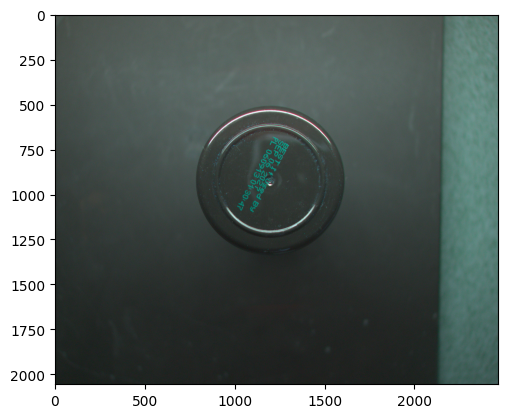

In [24]:
import matplotlib.pyplot as plt

plt.imshow(corrected_img)
plt.show()

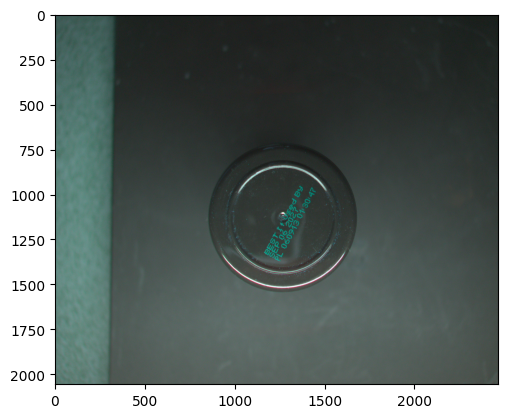

In [25]:
plt.imshow(org_img)
plt.show()

In [28]:
import math
from typing import Tuple, Union

import cv2
import numpy as np

from deskew import determine_skew


def rotate(
        image: np.ndarray, angle: float, background: Union[int, Tuple[int, int, int]]
) -> np.ndarray:
    old_width, old_height = image.shape[:2]
    angle_radian = math.radians(angle)
    width = abs(np.sin(angle_radian) * old_height) + abs(np.cos(angle_radian) * old_width)
    height = abs(np.sin(angle_radian) * old_width) + abs(np.cos(angle_radian) * old_height)

    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    rot_mat[1, 2] += (width - old_width) / 2
    rot_mat[0, 2] += (height - old_height) / 2
    return cv2.warpAffine(image, rot_mat, (int(round(height)), int(round(width))), borderValue=background)

image = cv2.imread('/Users/ngocthien.ai/Source/Projects/ocr_datecode/data/Code trên nắp chai/Image__2025-12-13__15-20-42.bmp')
grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
angle = determine_skew(grayscale)
rotated = rotate(image, angle, (0, 0, 0))
cv2.imwrite('output.png', rotated)

True